# Goals:
    - Create a Jupyter notebook tutorial for NCRF (we can refer tutorials from MNE and EELBRAIN)
        - it should be compatible with sphinx for documentation
    - Guide to setting up the environment and installing NCRF
        - this could be here or in the README
    - Provide an overview of NCRF:
        - What is NCRF? Provide an intuitive explaination with figures and equuations
        - What is NCRF used for? Why is it useful? 
        - What is the workflow of NCRF? Provide the diagram and maybe link parts of the code to the workflow
            - What are the types of data we can use for NCRF analysis? How to preprocess the data or use already preprocessed data? 
            - What are the visualizations tools available? 
            - Provide examples of different use cases of NCRF. 
            - Examples using dataset from different sources, tools to convert all datasets into a datatype like NDvar for NCRF or Eelbrain.



In [ ]:
# code for fixing channel location issue in appleseed data files
from pathlib import Path

root = Path('.')

import mne

import numpy as np

loc = np.array([

        0.09603   , -0.07437   ,  0.00905   , -0.5447052 , -0.83848277,

        0.01558496,  0.        , -0.01858388, -0.9998273 ,  0.8386276 ,

       -0.54461113,  0.01012274])

for s in root.iterdir():

    if s.name.startswith('.'):

        continue

    path = s / f'{s.name}_appleseed-raw.fif'
    print(path)

    raw = mne.io.read_raw_fif(s / f'{s.name}_appleseed-raw.fif', preload=True)

    index = raw.ch_names.index('MEG 056')

    raw.info['chs'][index]['loc'] = loc

    raw.save(path, overwrite=True)

# Guide to setting up the ncrf environment and installation
This can be moved to README later.\
Do we only support conda right now or can we use python venv an pip to create ncrf environment and install ncrf? \
Recommend python version and conda version so that all the dependencies install properly and depreciated packages should be updated or .

# Environment for development
Install Anaconda to create a conda environment for NCRF 

Guide for anaconda installation https://coderivers.org/blog/install-anaconda-python/   

Clone the github repository 

Once Anaconda is installed run the following command on the terminal, make sure you are in the NCRF directory 

"\$ conda env create --file=env-dev.yml" 

Activate the conda environment 

"\$ conda activate ncrf" 

Run the following command to install NCRF 

"(ncrf)\$ python setup.py install" - if depreciated then should we remove? 


# Provide an intuitive explaination of NCRF before getting into the examples

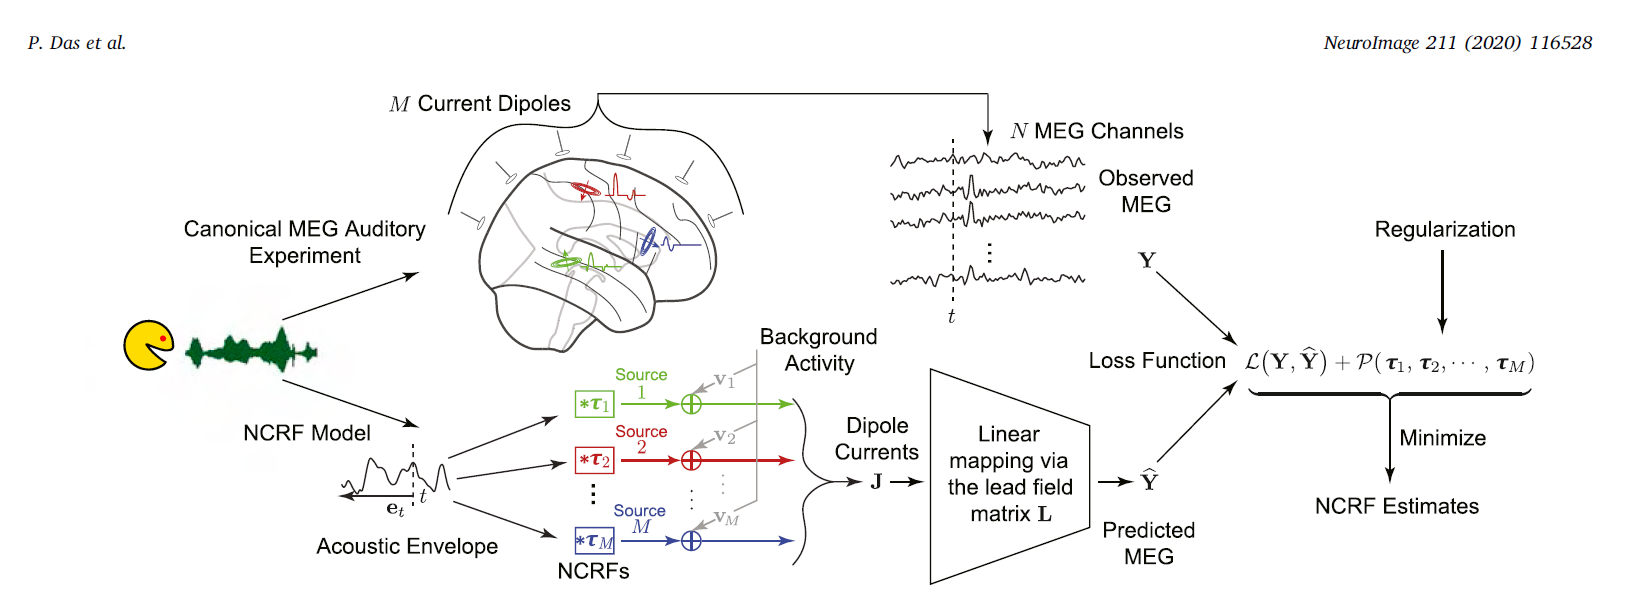

    - This could include a simple workflow diagram to get started
    - write a detailed explanation of NCRF with a mind map diagram on excalidraw/paint/just a png image, and link it here so that people can 






## Include MNE python introductory tutorial for MEG/EEG analysis. It will be useful to understand the data we are working with.
Use MNE python tutorials as reference for this https://mne.tools/stable/auto_tutorials/intro/10_overview.html
    
Integrate with NCRF tutorial so that users don't have to refer external sites often.


### Intuition for different statistical tests
    -Motivation behind the statistical tests
    -How each statistical test works
    -This should be updated as we add more statistical tests


### NCRF vs MNE - Mariyam
### Provide the workflow diagram in the beginning after NCRF explaination

# preprocessing -> Forward model (aka lead-field matrix) -> compute forward  solution from BEM -> lead-field matrix
# NCRF estimation -> estimate TRFs and source variances


MNE: typical M/EEG workflow https://mne.tools/stable/documentation/cookbook.html 

https://drive.google.com/file/d/1GPqj39bQ1qMIzyE5PCTS4dNhSu1kkK_E/view?usp=sharing


### Add a brief explaination about the data structures used at different parts of the tutorial

    -Human connectome dataset for speech
    
    -Does NCRF only work for human MEG data? 

    -Should all examples have ground truth data available for validation?
    -How to understand the metrics used for validation? 
        -principal orientation, principal time course and ground truth as well as selctivity
    -How to validate results without ground truth? cross validation with lowest generalization error? 

## From README
The magnetoencephalography (MEG) response to continuous auditory stimuli, such as speech, is commonly described using a linear filter, the auditory temporal response function (TRF). Though components of the sensor level TRFs have been well characterized, the cortical distributions of the underlying neural responses are not well-understood. NCRF provides a unified framework for determining the TRFs of neural sources directly from the MEG data, by integrating the TRF and distributed forward source models into one, and casting the joint estimation task as a Bayesian optimization problem. Though the resulting problem emerges as non-convex, we propose efficient solutions that leverage recent advances in evidence maximization.

This repository contains the implementation of our direct TRF estimation algorithm in python (version 3.6 and above)


In [ ]:
from eelbrain import *
a=Factor('aaaabb', name ='A')
a

In [ ]:
"""
Oddball Tones Example
=====================
Estimate NCRFs for standard and oddball tones.

For this tutorial, we use the auditory Brainstorm tutorial dataset :
cite:`Brainstorm` that is available as a part of the Brainstorm software.

.. contents:: Contents
   :local:

.. note::
   Downloading the dataset requires answering an interactive prompt (see
   :func:`mne.datasets.brainstorm.bst_auditory.data_path`).
"""
# Authors: Proloy Das <proloy@umd.edu>
#          Christian Brodbeck <brodbecc@mcmaster.ca>
#
# sphinx_gallery_thumbnail_number = 3

import numpy as np
import pandas as pd
import eelbrain
import mne
from ncrf import fit_ncrf
import matplotlib.pyplot as plt 

%matplotlib inline

In [ ]:
import numpy as np

import mne

subject = 'R2349'
sample_data_folder = "C:/Users/goku_/PycharmProjects/Data/Appleseed/meg/{}/".format(subject)

sample_data_raw_file = data_path +'{}_appleseed-raw.fif'.format(subject)

raw = mne.io.read_raw_fif(sample_data_raw_file)

print(raw)
print(raw.info)

# # raw = mne.io.read_raw_ctf(_fname, preload=False)
n_times_run1 = raw.n_times

# We mark a set of bad channels that seem noisier than others. 
raw.info['bads'] = []
with open(data_path + '{}_appleseed-bad_channels.txt'.format(subject), 'r') as f:
    for line in f:
        channel = line.strip()
        raw.info['bads'].append(channel)

<Raw | R2349_appleseed-raw.fif, 193 x 3464000 (3464.0 s), ~558 KiB, data not loaded>
<Info | 12 non-empty values
 bads: []
 ch_names: MEG 001, MEG 002, MEG 003, MEG 004, MEG 005, MEG 006, MEG 007, ...
 chs: 157 Magnetometers, 3 Reference Magnetometers, 32 misc, 1 Stimulus
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 1145 items (3 Cardinal, 5 HPI, 1137 Extra)
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 kit_system_id: 54 (University of Maryland, 2019-)
 lowpass: 200.0 Hz
 meas_date: 2020-02-26 21:30:27 UTC
 meas_id: 4 items (dict)
 nchan: 193
 projs: []
 sfreq: 1000.0 Hz
>


In [38]:
annotations_df = pd.DataFrame()
offset = n_times_run1
for idx in [1]:
    csv_fname = data_path + f'{subject}_appleseed-bad_channels.txt'
    df = pd.read_csv(csv_fname, header=None, names=['onset', 'duration', 'id', 'label'])
    print('Events from run {0}:'.format(idx))
    print(df)

    df['onset'] += offset * (idx - 1)
    annotations_df = pd.concat([annotations_df, df], axis=0)

Events from run 1:
     onset  duration  id  label
0  MEG 001       NaN NaN    NaN
1  MEG 016       NaN NaN    NaN
2  MEG 030       NaN NaN    NaN
3  MEG 056       NaN NaN    NaN
4  MEG 067       NaN NaN    NaN
5  MEG 099       NaN NaN    NaN
6  MEG 116       NaN NaN    NaN


TypeError: can only concatenate str (not "int") to str

In [27]:
events = mne.find_events(raw)
print(events)

[[   7447       0     162]
 [ 232045       0     167]
 [ 295397       0     162]
 [ 615699       0     167]
 [ 664607       0     162]
 [ 878005       0     167]
 [ 931443       0     162]
 [1141547       0     167]
 [1209797       0     162]
 [1445194       0     167]
 [1508562       0     162]
 [1778563       0     167]
 [1840026       0     162]
 [2071729       0     167]
 [2154589       0     162]
 [2404697       0     167]
 [2449727       0     162]
 [2781129       0     167]
 [2845935       0     162]
 [3077938       0     167]
 [3146723       0     162]
 [3431619       0     167]]


In [32]:
raw.ch_names

['MEG 001',
 'MEG 002',
 'MEG 003',
 'MEG 004',
 'MEG 005',
 'MEG 006',
 'MEG 007',
 'MEG 008',
 'MEG 009',
 'MEG 010',
 'MEG 011',
 'MEG 012',
 'MEG 013',
 'MEG 014',
 'MEG 015',
 'MEG 016',
 'MEG 017',
 'MEG 018',
 'MEG 019',
 'MEG 020',
 'MEG 021',
 'MEG 022',
 'MEG 023',
 'MEG 024',
 'MEG 025',
 'MEG 026',
 'MEG 027',
 'MEG 028',
 'MEG 029',
 'MEG 030',
 'MEG 031',
 'MEG 032',
 'MEG 033',
 'MEG 034',
 'MEG 035',
 'MEG 036',
 'MEG 037',
 'MEG 038',
 'MEG 039',
 'MEG 040',
 'MEG 041',
 'MEG 042',
 'MEG 043',
 'MEG 044',
 'MEG 045',
 'MEG 046',
 'MEG 047',
 'MEG 048',
 'MEG 049',
 'MEG 050',
 'MEG 051',
 'MEG 052',
 'MEG 053',
 'MEG 054',
 'MEG 055',
 'MEG 056',
 'MEG 057',
 'MEG 058',
 'MEG 059',
 'MEG 060',
 'MEG 061',
 'MEG 062',
 'MEG 063',
 'MEG 064',
 'MEG 065',
 'MEG 066',
 'MEG 067',
 'MEG 068',
 'MEG 069',
 'MEG 070',
 'MEG 071',
 'MEG 072',
 'MEG 073',
 'MEG 074',
 'MEG 075',
 'MEG 076',
 'MEG 077',
 'MEG 078',
 'MEG 079',
 'MEG 080',
 'MEG 081',
 'MEG 082',
 'MEG 083',
 'ME

In [ ]:

# The event timing is adjusted by comparing the trigger times on detected sound onsets on channel UADC001-4408.
sound_data = raw[raw.ch_names.index('MEG 001')][0][0]
onsets = np.where(np.abs(sound_data) > 2. * np.std(sound_data))[0]
min_diff = int(0.5 * raw.info['sfreq'])
diffs = np.concatenate([[min_diff + 1], np.diff(onsets)])
onsets = onsets[diffs > min_diff]
assert len(onsets) == len(events)
diffs = 1000. * (events[:, 0] - onsets) / raw.info['sfreq']
print('Trigger delay removed (μ ± σ): %0.1f ± %0.1f ms'
      % (np.mean(diffs), np.std(diffs)))

[      0    6072    9982   20372   22199   24915   35259   46092   71239
   77051   93416  119105  121718  174994  191909  211378  213615  218513
  221107  225309  228016  233694  236665  242720  246652  249217  251918
  253736  258593  261300  264208  265617  269195  273399  274566  277129
  277878  280688  281723  287145  290017  291655  294936  296872  298073
  304380  308253  332984  367846  391640  396532  398870  488302  533201
  534157  538148  561918  597978  600715  604959  608613  609822  616311
  617068  620384  630193  631396  632270  640903  641668  642685  645813
  647813  649134  653256  656136  657084  660058  666314  670332  685188
  699096  724529  750275  762625  770892  778140  798851  818969  843513
  856153  880530  884315  886225  891210  892326  892923  894532  895792
  897393  898156  900926  903037  904355  905903  907316  908539  909548
  911638  912384  919498  921811  922884  923624  930488  933001  937416
  957701  960891  963323  974725  985680  986865  9

AssertionError: 

In [37]:
# events times are rescaled according to new sampling freq, 100 Hz
events[:, 0] = np.int64(onsets * 100 / raw.info['sfreq'])
mne.write_events(event_fname, events, overwrite=True)

del sound_data, diffs

ValueError: could not broadcast input array from shape (426,) into shape (22,)

ValueError: No matching events found for 1 (event id 1)

In [ ]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

In [ ]:
# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)
ica.exclude = [1, 2]  # details on how we picked these are omitted here
ica.plot_properties(raw, picks=ica.exclude)

In [ ]:
orig_raw = raw.copy()
raw.load_data()
ica.apply(raw)

# show some frontal channels to clearly illustrate the artifact removal
chs = [
    "MEG 001",
    "MEG 015",
    "MEG 013",
    "MEG 021",
    "MEG 022",
    "MEG 023",
    "MEG 031",
    "MEG 032",
    "MEG 033",
    "MEG 151",
    "MEG 152",
    "MEG 153",
]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
orig_raw.plot(order=chan_idxs, start=12, duration=4)
raw.plot(order=chan_idxs, start=12, duration=4)

In [ ]:
events = mne.find_events(raw, stim_channel="STI 014")
print(events[:5])  # show the first 5

In [ ]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "smiley": 5,
    "buttonpress": 32,
}

In [ ]:
fig = mne.viz.plot_events(
    events, event_id=event_dict, sfreq=raw.info["sfreq"], first_samp=raw.first_samp
)

In [ ]:
# import os.path as op
# import hcp
# storage_dir = op.expanduser('C:/Users/goku_/mne_data/hcp')
# hcp.make_mne_anatomy(
#      '255639', subjects_dir=storage_dir + '/subjects',
#      hcp_path=storage_dir + '/HCP',
#      recordings_path=storage_dir + '/hcp-meg')

include more example datasets from openneuro

In [ ]:
# Preprocessing
# -------------
# Preprocess MEG Data: low pass filtering, power line attenuation, downsampling, etc.
# We broadly follow `this mne-python tutorial <https://mne.tools/stable/auto_tutorials/io/60_ctf_bst_auditory.html>`_.
# we should create the path if doesn't exist

subject = 'R2349'
data_path = "C:/Users/goku_/PycharmProjects/Data/Appleseed/meg/{}/".format(subject)


raw_fname = data_path +'{}_appleseed-raw.fif'.format(subject)

# data_path = mne.datasets.brainstorm.bst_auditory.data_path()
# raw_fname = data_path / 'MEG' / 'bst_auditory' / 'S01_AEF_20131218_01.ds'

# data_path = "C:/Users/goku_/mne_data/Appleseed/"
# _fname = 'C:/Users/goku_/mne_data/Appleseed/Appleseed/meg/{}/{}_appleseed-raw.fif'.format(subject, subject)
raw = mne.io.read_raw_fif(raw_fname, preload=False)


# # raw = mne.io.read_raw_ctf(_fname, preload=False)
n_times_run1 = raw.n_times

# We mark a set of bad channels that seem noisier than others. 
raw.info['bads'] = []
with open(data_path + '{}_appleseed-bad_channels.txt'.format(subject), 'r') as f:
    for line in f:
        channel = line.strip()
        raw.info['bads'].append(channel)
# raw.info['bads'] = ['MEG 056'] # where are we getting this info from? how do we know which channels are bad? 

annotations_df = pd.DataFrame()
offset = n_times_run1
for idx in [1]:
    csv_fname = data_path + '{}_appleseed-bad_channels.txt'.format(subject)
    df = pd.read_csv(csv_fname, header=None, names=['onset', 'duration', 'id', 'label'])
    print('Events from run {0}:'.format(idx))
    print(df)

    df['onset'] += offset * (idx - 1)
    annotations_df = pd.concat([annotations_df, df], axis=0)
    annotations = mne.Annotations(onset=annotations_df['onset'] / raw.info['sfreq'],
                              duration=annotations_df['duration'] / raw.info['sfreq'],
                              description=annotations_df['label'])

In [ ]:

# Conversion from samples to times:
onsets = annotations_df['onset'].values / raw.info['sfreq']
durations = annotations_df['duration'].values / raw.info['sfreq']
descriptions = annotations_df['label'].values

annotations = mne.Annotations(onsets, durations, descriptions)
raw.set_annotations(annotations)
del onsets, durations, descriptions

In [ ]:
# events are the presentation times of the audio stimuli: UPPT001
event_fname = data_path / 'MEG' / 'bst_auditory' / 'S01_AEF_20131218_01-eve.fif'
events = mne.find_events(raw, stim_channel='UPPT001')
# The event timing is adjusted by comparing the trigger times on detected sound onsets on channel UADC001-4408.
sound_data = raw[raw.ch_names.index('UADC001-4408')][0][0]

onsets = np.where(np.abs(sound_data) > 2. * np.std(sound_data))[0]

min_diff = int(0.5 * raw.info['sfreq'])
diffs = np.concatenate([[min_diff + 1], np.diff(onsets)])
onsets = onsets[diffs > min_diff]
assert len(onsets) == len(events)
diffs = 1000. * (events[:, 0] - onsets) / raw.info['sfreq']
print('Trigger delay removed (μ ± σ): %0.1f ± %0.1f ms'
      % (np.mean(diffs), np.std(diffs)))



fig = plt.figure()

ax1, ax2, ax3, ax4 = fig.add_subplot(4,1,1), fig.add_subplot(4,1,2), fig.add_subplot(4,1,3), fig.add_subplot(4,1,4)

ax1.plot(sound_data[:1000])

ax2.plot(onsets)

ax3.plot(diffs)

ax4.plot(events)

plt.tight_layout()

In [ ]:
# events times are rescaled according to new sampling freq, 100 Hz
events[:, 0] = np.int64(onsets * 100 / raw.info['sfreq'])
mne.write_events(event_fname, events, overwrite=True)

del sound_data, diffs

## set EEG  channel 
raw.set_eeg_reference('average', projection=True)
# raw_AEF.plot_psd(tmax=60., average=False)
raw.load_data()

In [ ]:

notch = raw.notch_filter(np.arange(60, 181, 60), fir_design='firwin')

# band pass filtering 1-8 Hz
filter = raw.filter(1.0, 8.0, fir_design='firwin')

# resample to 100 Hz
resample = raw.resample(100, npad="auto")

#<class 'mne.io.ctf.ctf.RawCTF'> dig into it more 

In [ ]:
print(type(filter))


In [ ]:

raw.plot_sensors(ch_type='mag')

In [ ]:

### LOAD RELEVANT VARIABLES AS eelbrain.NDVar
# load as epochs for plot only
ds = eelbrain.load.fiff.events(raw=raw, proj=True, stim_channel='UPPT001', events=event_fname)
epochs = eelbrain.load.fiff.epochs(ds, tmin=-0.1, tmax=0.5, baseline=(None, 0))
eelbrain.plot.Butterfly(epochs)


In [ ]:

# pick MEG channels
picks = mne.pick_types(raw.info, meg=True, eeg=False, stim=False, eog=False,
                       ref_meg=False, exclude='bads')


In [ ]:

# Read as a single chunk of data
y, t = raw.get_data(picks, return_times=True)
sensor_dim = eelbrain.load.fiff.sensor_dim(raw.info, picks=picks)
time = eelbrain.UTS.from_int(0, t.size - 1, raw.info['sfreq'])
meg = eelbrain.NDVar(y, dims=(sensor_dim, time))
print(meg)


In [ ]:
print(meg.shape)
print(type(meg))
m = meg[1, :10]
print(m)
print(m.shape)
# plt.plot(m)
#investigate ndvar datatype

In [ ]:

###############################################################################
# Continuous stimulus variable construction
# -----------------------------------------
# After loading and processing the raw data, we will construct the predictor variable for 
# this particular experiment (by putting an impulse at every event time-point). 
# Note that, the predictor variable and meg response should be of same length. 
# 
# In case of repetitive trials (where you will have a :class:`eelbrain.Case` dimension), 
# supply one predictor variable for each trial. Different predictor variables for a single trial 
# can be nested (see :func:`ncrf.fit_ncrf`).
# 
# In this example, we use two different predictor variables for a single trial

# For the common response, we put impulses at the presentation times of both the audio stimuli (i.e., all beeps).
stim1 = np.zeros(len(time))
stim1[events[:, 0]] = 1.



In [ ]:

# To distinguish between standard and deviant beeps, we assign 1 and -1 impulses respectively.
stim2 = stim1.copy()
stim2[events[np.where(events[:, 2] == 2), 0]] = -1.
stim1 = eelbrain.NDVar(stim1, time)
stim2 = eelbrain.NDVar(stim2, time)


In [ ]:
# Visualize the stimulus
# p = eelbrain.plot.LineStack(eelbrain.combine([stim1, stim2]), w=10, h=2.5, legend=False)
p = eelbrain.plot.UTS([stim1, stim2], color='black', stem=True, frame='none', w=10, h=2.5, legend=False)


In [ ]:

###############################################################################
# Noise covariance estimation
# ---------------------------
# Here we estimate the noise covariance from empty room data.
# Instead, you can also use pre-stimulus recordings to compute noise covariance.

noise_path = data_path / 'MEG' / 'bst_auditory' / 'S01_Noise_20131218_01.ds'
raw_empty_room = mne.io.read_raw_ctf(noise_path, preload=True)

   

In [ ]:

# Apply the same pre-processing steps to empty room data
raw_empty_room.notch_filter(np.arange(60, 181, 60), fir_design='firwin')

raw_empty_room.filter(1.0, 8.0, fir_design='firwin')

raw_empty_room.resample(100, npad="auto")


In [ ]:

# Compute the noise covariance matrix
noise_cov = mne.compute_raw_covariance(raw_empty_room, tmin=0, tmax=None, method='shrunk', rank=None)
print(noise_cov)


In [ ]:

###############################################################################
# Forward model (aka lead-field matrix)
# -------------------------------------
# Now is the time for forward modeling.
# 'ico-4' should be sufficient resolution if working with surface source space.
# You can choose to work with free or constrained lead fields.
# :func`ncrf.fit_ncrf` will choose the appropriate regularizer by looking at the provided lead-field matrix.

# The paths to FreeSurfer reconstructions
subjects_dir = data_path / 'subjects'
subject = 'bst_auditory'

# mne.viz.plot_bem(subject=subject, subjects_dir=subjects_dir,
#                  brain_surfaces='white', orientation='coronal')


In [ ]:

# The transformation file obtained by coregistration

trans = data_path / 'MEG' / 'bst_auditory' / 'bst_auditory-trans.fif'

# Here we look at the head only.
# mne.viz.plot_alignment(raw.info, trans, subject=subject, dig=True,
#                        meg=['helmet', 'sensors'], subjects_dir=subjects_dir,
#                        surfaces='head')


In [ ]:

srcfile = subjects_dir / 'bst_auditory' / 'bem' / 'bst_auditory-ico-4-src.fif'
if srcfile.is_file():
    src = mne.read_source_spaces(srcfile)
else:
    src = mne.setup_source_space(subject, spacing='ico4',
                                 subjects_dir=subjects_dir, add_dist=False)
    mne.add_source_space_distances(src)
    mne.write_source_spaces(srcfile, src, overwrite=True)  # needed for smoothing
src


In [ ]:

###############################################################################
# Compute the forward solution:
fwdfile = subjects_dir / 'bst_auditory' / 'bem' / 'bst_auditory-ico-4-fwd.fif'
if fwdfile.is_file():
    fwd = mne.read_forward_solution(fwdfile)
else:
    conductivity = (0.3,)  # for single layer
    # conductivity = (0.3, 0.006, 0.3)  # for three layers
    model = mne.make_bem_model(subject=subject, ico=4,
                               conductivity=conductivity,
                               subjects_dir=subjects_dir)
    bem = mne.make_bem_solution(model)

    fwd = mne.make_forward_solution(raw.info, trans=trans, src=src, bem=bem,
                                    meg=True, eeg=False, mindist=5.0, n_jobs=2)
    mne.write_forward_solution(fwdfile, fwd)

fwd


In [ ]:

###############################################################################
# Extract the fixed orientation lead field matrix:
fwd_fixed = mne.convert_forward_solution(
    fwd, surf_ori=True, force_fixed=True, use_cps=True)

# leadfield matrix
lf = eelbrain.load.fiff.forward_operator(fwd_fixed, src='ico-4', subjects_dir=subjects_dir)



In [ ]:

###############################################################################
# NCRF estimation
# ---------------
# Now that we have all the required data to estimate NCRFs.
#
# .. note::
#    This example uses simplified settings to speed up estimation:
#
#    1) For this example, we use a fixed regularization parameter (``mu``).
#    For a real experiment, the optimal ``mu`` would be determined by
#    cross-validation (set ``mu='auto'``, which is the default).
#    The optimal ``mu`` will then be stored in ``model.mu``
#    (this is how the ``mu`` used here was determined).
#
#    2) The example forces the estimation to stop after fewer iterations than
#    is recommended (``n_iter``). For stable models, we recommend to use the
#    default setting (``n_iter=10``).

# To speed up the example, we cache the NCRF:
ncrf_file = data_path / 'MEG' / 'bst_auditory' / 'oddball_ncrf.pickle'
if ncrf_file.exists():
    model = eelbrain.load.unpickle(ncrf_file)
else:
    model = fit_ncrf(
        meg, [stim1, stim2], lf, noise_cov, tstart=0, tstop=0.5,
        mu=0.0001756774187547859, n_iter=5,
    )
    eelbrain.save.pickle(model, ncrf_file)



In [ ]:

###############################################################################
# The learned kernel/filter (the NCRF) can be accessed as an attribute of the
# ``model``.
# NCRFs are stored as :class:`eelbrain.NDVar`. Here, the two NCRFs correspond
# to the two different predictor variables:

model.h




In [ ]:

###############################################################################
# Visualization
# -------------
# A butterfly plot shows weights in all sources over time.
# This is good for forming a quick impression of important time lags,
# or peaks in the response:
# 
# .. note::
#    Since the estimates are sparse over cortical locations, smoothing the NCRFs over sources to make the visualization more intuitive.

h = [h.smooth('source', 0.01, 'gaussian') for h in model.h]
p = eelbrain.plot.Butterfly(h)


In [ ]:

###############################################################################
# The following code for plotting the anatomical localization
# is commented because the `Mayavi <https://docs.enthought.com/mayavi/mayavi>`_
# based plots do not
# work reliably in the automatic documentation.
# Uncomment it to create anatomical plots.
#
# A single time point can be visualized with the PySurfer (:mod:`surfer`)
# based :func:`eelbrain.plot.brain.brain`:

brain = eelbrain.plot.brain.brain(h[0].sub(time=0.140), vmax=2e-11, surf='pial')


In [ ]:

###############################################################################
# An :class:`eelbrain.plot.brain.SequencePlotter` can be used to plot a
# sequence of brain images, for example in a jupyter notebook:

h_binned = h[0].bin(0.1, 0.1, 0.4, 'extrema')
sp = eelbrain.plot.brain.SequencePlotter()
sp.set_brain_args(surf='inflated')
sp.add_ndvar(h_binned)
p = sp.plot_table(view='lateral')

###############################################################################
# In an interactive iPython session, we can also use interactive time-linked
# plots with :func:`eelbrain.plot.brain.butterfly`:

brain, butterfly = eelbrain.plot.brain.butterfly(h[0])
